# Exploring the Latent Space of StyleGAN2 with Different Cat Images

This uses a pretrained **StyleGAN2-ADA AFHQ Cat** model to generate different realistic cat images. Random latent vectors produce different faces; interpolation shows a gradual transition between two generated faces, and latent-dimension changes are compared.


In [1]:
# Clone the official StyleGAN2-ADA repository
!git clone https://github.com/NVlabs/stylegan2-ada-pytorch.git

# Move into the repository
%cd stylegan2-ada-pytorch

# Install required packages
!pip install ninja imageio imageio-ffmpeg -q

Cloning into 'stylegan2-ada-pytorch'...
remote: Enumerating objects: 131, done.
remote: Counting objects: 100% (2/2), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 131 (delta 0), reused 0 (delta 0), pack-reused 129 (from 2)
Receiving objects: 100% (131/131), 1.13 MiB | 16.78 MiB/s, done.
Resolving deltas: 100% (57/57), done.
/content/stylegan2-ada-pytorch
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.4/183.4 kB 9.1 MB/s eta 0:00:00


## Loading a Pretrained StyleGAN2 Model

The AFHQ Cat pretrained StyleGAN2-ADA model is used to generate cat images. The model is already trained, so this notebook does not train a GAN from scratch. Different random latent vectors are used to generate different faces.


In [2]:
# Download the pretrained StyleGAN2-ADA AFHQ cat model
import os

model_url = "https://nvlabs-fi-cdn.nvidia.com/stylegan2-ada-pytorch/pretrained/afhqcat.pkl"
if not os.path.exists("afhqcat.pkl"):
    !wget -q -O afhqcat.pkl {model_url}

print("AFHQ cat pretrained model is ready.")


AFHQ cat pretrained model is ready.


## Loading the Model

The pretrained StyleGAN2 model is loaded using PyTorch.
The model takes a latent vector as input and generates an image.

In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import imageio
from PIL import Image
from IPython.display import display

import legacy

# Select GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Load the pretrained AFHQ Cat model
with open("afhqcat.pkl", "rb") as f:
    network = legacy.load_network_pkl(f)

G = network["G_ema"].to(device)
G.eval()

print("StyleGAN2-ADA AFHQ Cat model loaded successfully.")
print("Latent vector dimension:", G.z_dim)


Device: cuda
StyleGAN2-ADA AFHQ Cat model loaded successfully.
Latent vector dimension: 512


## Image Generation Function

The following function takes a latent vector and generates an image using the pretrained StyleGAN2 model.

In [4]:
def generate_image(z, truncation_psi=0.7):
    """Generate one cat image from a latent vector."""
    with torch.no_grad():
        image = G(z, None, truncation_psi=truncation_psi)

    # Convert image values from [-1, 1] to [0, 255]
    image = (image.permute(0, 2, 3, 1) * 127.5 + 128).clamp(0, 255).to(torch.uint8)
    return image[0].cpu().numpy()

print("Cat-image generation function created.")


Cat-image generation function created.


In [5]:
# Use different seeds to create distinct cat faces.
# Change these seed values to generate another set of faces.
seed1, seed2 = 2026, 9090

generator1 = torch.Generator(device=device).manual_seed(seed1)
generator2 = torch.Generator(device=device).manual_seed(seed2)
z1 = torch.randn([1, G.z_dim], generator=generator1, device=device)
z2 = torch.randn([1, G.z_dim], generator=generator2, device=device)

print("Latent vectors generated with seeds:", seed1, "and", seed2)
print("z1 shape:", z1.shape)
print("z2 shape:", z2.shape)


Latent vectors generated with seeds: 2026 and 9090
z1 shape: torch.Size([1, 512])
z2 shape: torch.Size([1, 512])


Setting up PyTorch plugin "bias_act_plugin"... Failed!


/content/stylegan2-ada-pytorch/torch_utils/ops/bias_act.py:50: UserWarning: Failed to build CUDA kernels for bias_act. Falling back to slow reference implementation. Details:

Traceback (most recent call last):
  File "/content/stylegan2-ada-pytorch/torch_utils/ops/bias_act.py", line 48, in _init
    _plugin = custom_ops.get_plugin('bias_act_plugin', sources=sources, extra_cuda_cflags=['--use_fast_math'])
  File "/content/stylegan2-ada-pytorch/torch_utils/custom_ops.py", line 111, in get_plugin
    module = importlib.import_module(module_name)
  File "/usr/lib/python3.13/importlib/__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1395, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No module 

Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!


/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py:34: UserWarning: Failed to build CUDA kernels for upfirdn2d. Falling back to slow reference implementation. Details:

Traceback (most recent call last):
  File "/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py", line 32, in _init
    _plugin = custom_ops.get_plugin('upfirdn2d_plugin', sources=sources, extra_cuda_cflags=['--use_fast_math'])
  File "/content/stylegan2-ada-pytorch/torch_utils/custom_ops.py", line 111, in get_plugin
    module = importlib.import_module(module_name)
  File "/usr/lib/python3.13/importlib/__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1395, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No mod

Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!


/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py:34: UserWarning: Failed to build CUDA kernels for upfirdn2d. Falling back to slow reference implementation. Details:

Traceback (most recent call last):
  File "/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py", line 32, in _init
    _plugin = custom_ops.get_plugin('upfirdn2d_plugin', sources=sources, extra_cuda_cflags=['--use_fast_math'])
  File "/content/stylegan2-ada-pytorch/torch_utils/custom_ops.py", line 111, in get_plugin
    module = importlib.import_module(module_name)
  File "/usr/lib/python3.13/importlib/__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1395, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No mod

Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... 

/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py:34: UserWarning: Failed to build CUDA kernels for upfirdn2d. Falling back to slow reference implementation. Details:

Traceback (most recent call last):
  File "/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py", line 32, in _init
    _plugin = custom_ops.get_plugin('upfirdn2d_plugin', sources=sources, extra_cuda_cflags=['--use_fast_math'])
  File "/content/stylegan2-ada-pytorch/torch_utils/custom_ops.py", line 111, in get_plugin
    module = importlib.import_module(module_name)
  File "/usr/lib/python3.13/importlib/__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1395, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No mod

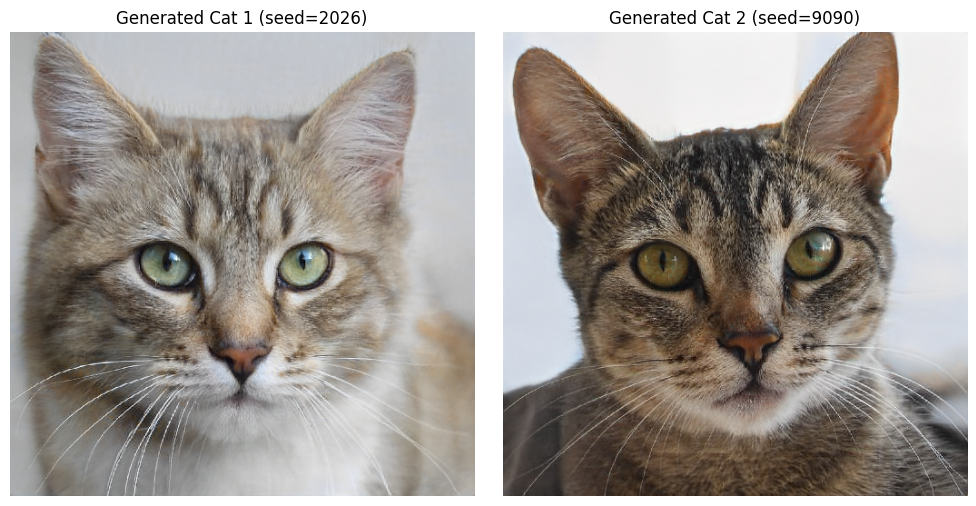

In [6]:
# Generate two different cat faces
image1 = generate_image(z1)
image2 = generate_image(z2)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image1)
plt.title(f"Generated Cat 1 (seed={seed1})")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(image2)
plt.title(f"Generated Cat 2 (seed={seed2})")
plt.axis("off")
plt.tight_layout()
plt.show()


In [7]:
# Save the two generated cat images
imageio.imwrite("cat_seed1.png", image1)
imageio.imwrite("cat_seed2.png", image2)

print("Saved cat_seed1.png and cat_seed2.png")


Saved cat_seed1.png and cat_seed2.png


## Saving the Generated Cat Images

The two generated face images are saved as PNG files. Change `seed1` and `seed2` in the latent-vector cell and rerun the cells to generate another pair of faces.


In [8]:
# Save the initial generated faces
imageio.imwrite("cat_seed1.png", image1)
imageio.imwrite("cat_seed2.png", image2)

print("Cat 1 saved as cat_seed1.png")
print("Cat 2 saved as cat_seed2.png")


Cat 1 saved as cat_seed1.png
Cat 2 saved as cat_seed2.png


## Linear Interpolation Between Two Cat Images

Linear interpolation creates intermediate latent vectors between `z1` and `z2`:

\[
z(t) = (1-t)z_1 + tz_2
\]

As `t` moves from 0 to 1, the generated images transition from the first face to the second face.


In [9]:
# Number of intermediate images
num_intermediate = 10

# Total number of images
# First image + 10 intermediate images + final image
num_frames = num_intermediate + 2

# Values of t from 0 to 1
alphas = np.linspace(0, 1, num_frames)

frames = []

for alpha in alphas:

    # Linear interpolation
    z_interpolated = (1 - alpha) * z1 + alpha * z2

    # Generate image
    img = generate_image(z_interpolated)

    frames.append(img)

print("Total images generated:", len(frames))

Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... 

/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py:34: UserWarning: Failed to build CUDA kernels for upfirdn2d. Falling back to slow reference implementation. Details:

Traceback (most recent call last):
  File "/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py", line 32, in _init
    _plugin = custom_ops.get_plugin('upfirdn2d_plugin', sources=sources, extra_cuda_cflags=['--use_fast_math'])
  File "/content/stylegan2-ada-pytorch/torch_utils/custom_ops.py", line 111, in get_plugin
    module = importlib.import_module(module_name)
  File "/usr/lib/python3.13/importlib/__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1395, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No mod

Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plu

/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py:34: UserWarning: Failed to build CUDA kernels for upfirdn2d. Falling back to slow reference implementation. Details:

Traceback (most recent call last):
  File "/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py", line 32, in _init
    _plugin = custom_ops.get_plugin('upfirdn2d_plugin', sources=sources, extra_cuda_cflags=['--use_fast_math'])
  File "/content/stylegan2-ada-pytorch/torch_utils/custom_ops.py", line 111, in get_plugin
    module = importlib.import_module(module_name)
  File "/usr/lib/python3.13/importlib/__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1395, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No mod

Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... 

...

/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py:34: UserWarning: Failed to build CUDA kernels for upfirdn2d. Falling back to slow reference implementation. Details:

Traceback (most recent call last):
  File "/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py", line 32, in _init
    _plugin = custom_ops.get_plugin('upfirdn2d_plugin', sources=sources, extra_cuda_cflags=['--use_fast_math'])
  File "/content/stylegan2-ada-pytorch/torch_utils/custom_ops.py", line 111, in get_plugin
    module = importlib.import_module(module_name)
  File "/usr/lib/python3.13/importlib/__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1395, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No mod

Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... 

/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py:34: UserWarning: Failed to build CUDA kernels for upfirdn2d. Falling back to slow reference implementation. Details:

Traceback (most recent call last):
  File "/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py", line 32, in _init
    _plugin = custom_ops.get_plugin('upfirdn2d_plugin', sources=sources, extra_cuda_cflags=['--use_fast_math'])
  File "/content/stylegan2-ada-pytorch/torch_utils/custom_ops.py", line 111, in get_plugin
    module = importlib.import_module(module_name)
  File "/usr/lib/python3.13/importlib/__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1395, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No mod

Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plu

/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py:34: UserWarning: Failed to build CUDA kernels for upfirdn2d. Falling back to slow reference implementation. Details:

Traceback (most recent call last):
  File "/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py", line 32, in _init
    _plugin = custom_ops.get_plugin('upfirdn2d_plugin', sources=sources, extra_cuda_cflags=['--use_fast_math'])
  File "/content/stylegan2-ada-pytorch/torch_utils/custom_ops.py", line 111, in get_plugin
    module = importlib.import_module(module_name)
  File "/usr/lib/python3.13/importlib/__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1395, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No mod

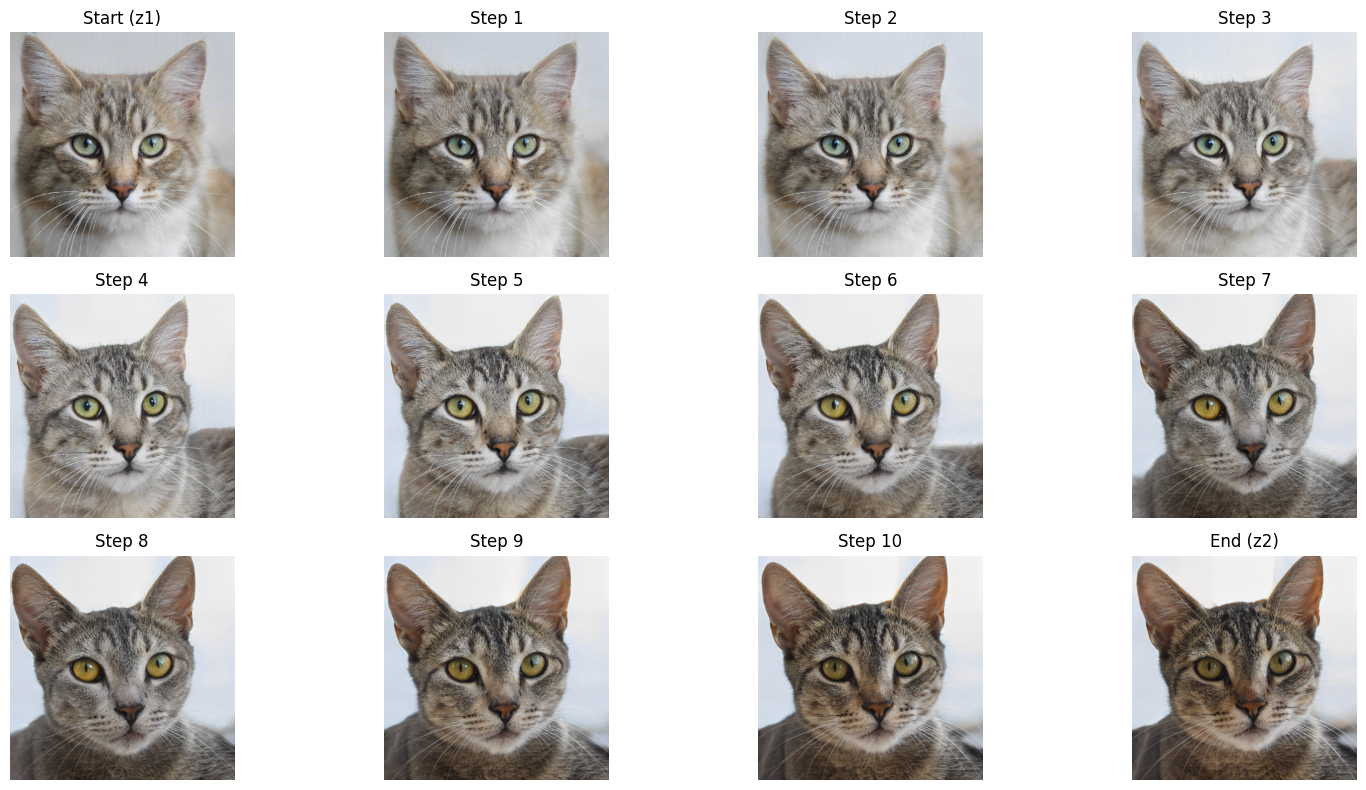

In [ ]:
# Display all interpolation images
plt.figure(figsize=(16, 8))

for i, img in enumerate(frames):
    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    if i == 0:
        title = "Start (z1)"
    elif i == len(frames) - 1:
        title = "End (z2)"
    else:
        title = f"Step {i}"
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()


## Creating an Image Strip

All interpolation frames are resized and arranged horizontally. The resulting strip visualizes the gradual transition between the two generated cat faces.


Saved cat_interpolation_strip.png


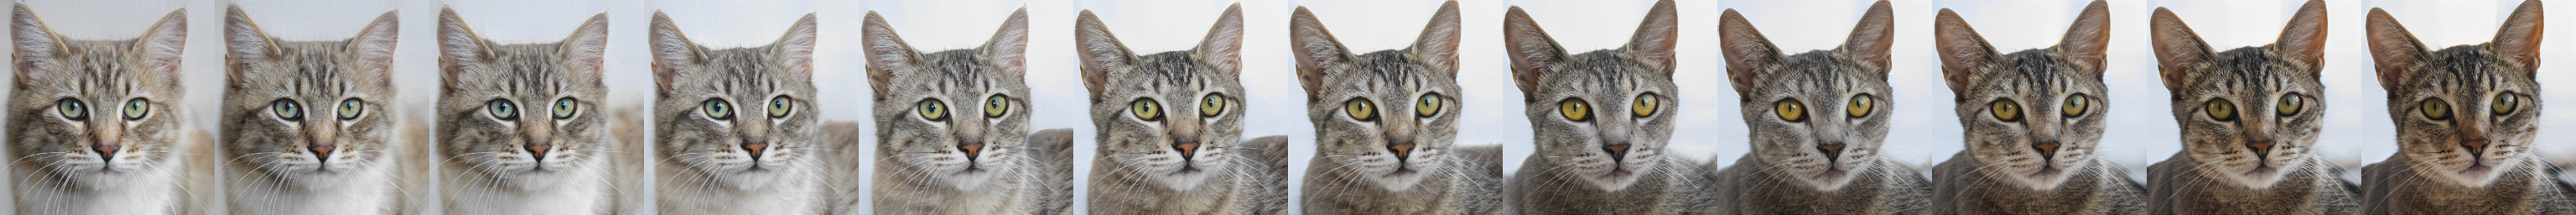

In [ ]:
# Convert interpolation images to PIL format and resize them
pil_frames = [Image.fromarray(img).resize((256, 256)) for img in frames]

# Create a horizontal image strip
strip = Image.new("RGB", (256 * len(pil_frames), 256))
for i, img in enumerate(pil_frames):
    strip.paste(img, (i * 256, 0))

strip.save("cat_interpolation_strip.png")
print("Saved cat_interpolation_strip.png")
display(strip)


## Creating a GIF

A GIF is created from the interpolation frames to show the continuous transition between the two generated cat faces.


In [10]:
imageio.mimsave(
    "cat_latent_interpolation.gif",
    frames,
    duration=0.5,
    loop=0
)
print("GIF created: cat_latent_interpolation.gif")


GIF created: cat_latent_interpolation.gif


Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!


/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py:34: UserWarning: Failed to build CUDA kernels for upfirdn2d. Falling back to slow reference implementation. Details:

Traceback (most recent call last):
  File "/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py", line 32, in _init
    _plugin = custom_ops.get_plugin('upfirdn2d_plugin', sources=sources, extra_cuda_cflags=['--use_fast_math'])
  File "/content/stylegan2-ada-pytorch/torch_utils/custom_ops.py", line 111, in get_plugin
    module = importlib.import_module(module_name)
  File "/usr/lib/python3.13/importlib/__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1395, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No mod

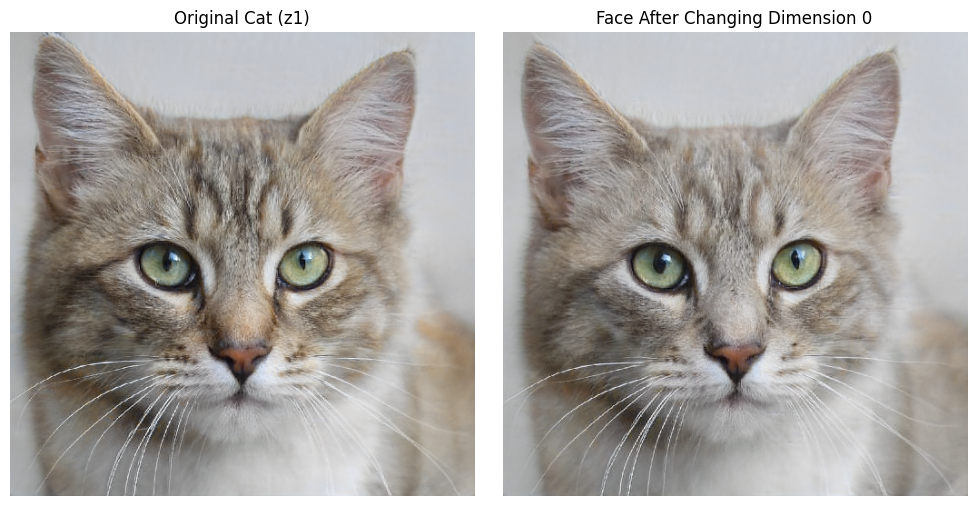

In [11]:
# Change latent dimension 0 and compare the generated face
z_modified = z1.clone()
z_modified[0, 0] += 3.0
modified_image = generate_image(z_modified)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image1)
plt.title("Original Cat (z1)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(modified_image)
plt.title("Face After Changing Dimension 0")
plt.axis("off")
plt.tight_layout()
plt.show()


Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!


/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py:34: UserWarning: Failed to build CUDA kernels for upfirdn2d. Falling back to slow reference implementation. Details:

Traceback (most recent call last):
  File "/content/stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py", line 32, in _init
    _plugin = custom_ops.get_plugin('upfirdn2d_plugin', sources=sources, extra_cuda_cflags=['--use_fast_math'])
  File "/content/stylegan2-ada-pytorch/torch_utils/custom_ops.py", line 111, in get_plugin
    module = importlib.import_module(module_name)
  File "/usr/lib/python3.13/importlib/__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1395, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_load_unlocked
ModuleNotFoundError: No mod

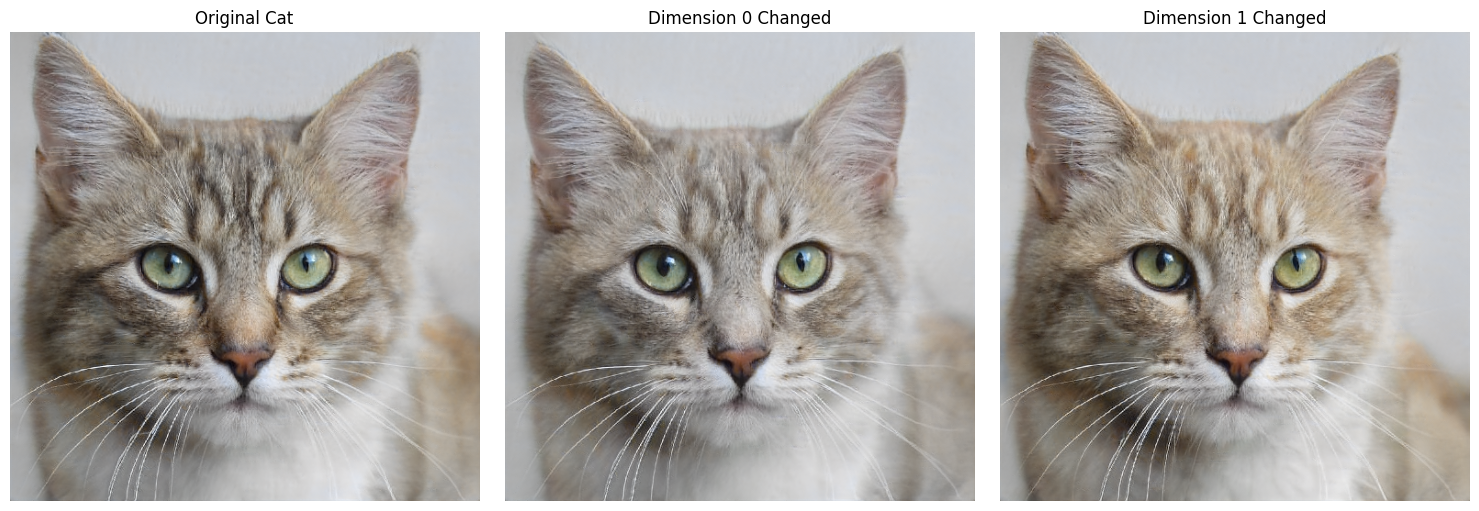

In [12]:
# Compare the original face with changes to two latent dimensions
z_modified2 = z1.clone()
z_modified2[0, 1] += 3.0
modified_image2 = generate_image(z_modified2)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(image1)
plt.title("Original Cat")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(modified_image)
plt.title("Dimension 0 Changed")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(modified_image2)
plt.title("Dimension 1 Changed")
plt.axis("off")
plt.tight_layout()
plt.show()


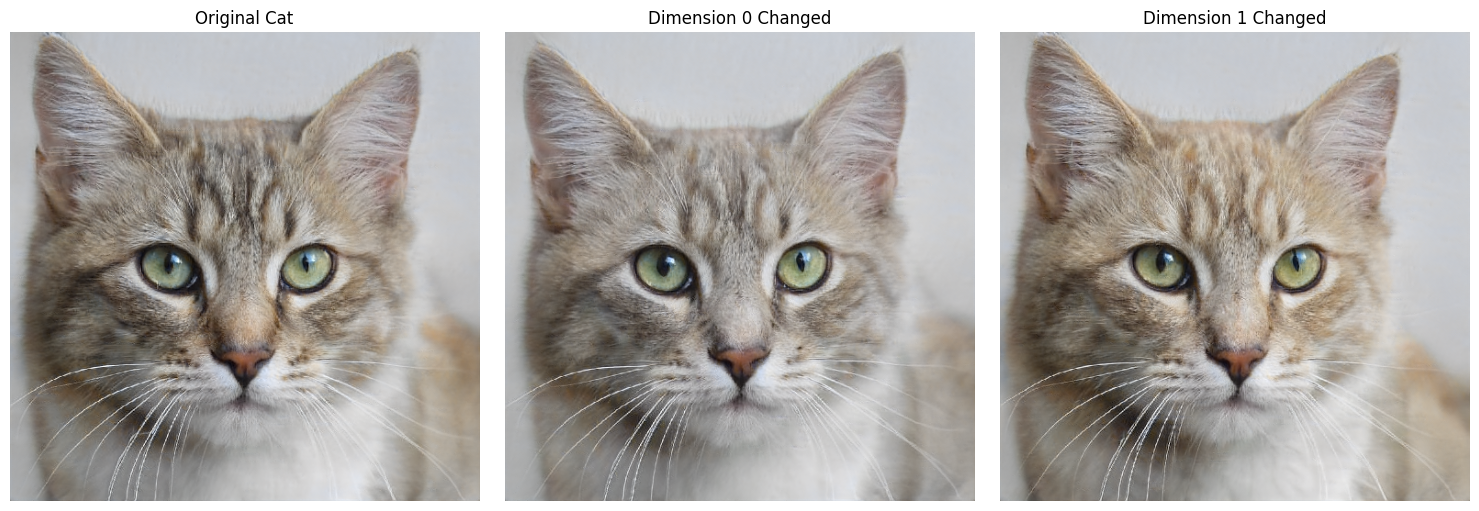

Saved cat_latent_dimension_comparison.png


In [13]:
# Save the latent-dimension comparison
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image1)
plt.title("Original Cat")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(modified_image)
plt.title("Dimension 0 Changed")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(modified_image2)
plt.title("Dimension 1 Changed")
plt.axis("off")

plt.tight_layout()
plt.savefig("cat_latent_dimension_comparison.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved cat_latent_dimension_comparison.png")


## Conclusion

This experiment uses a pretrained StyleGAN2-ADA AFHQ Cat model to generate different cat faces from random latent vectors. Linear interpolation creates intermediate faces between two latent vectors. Modifying individual latent dimensions produces additional variations, which can be compared with the original face. The notebook saves the generated faces, interpolation strip, GIF, and latent-dimension comparison.


**Question:** What did you observe between the original and generated images?

**Answer:** The two random latent vectors generated different cat faces. During interpolation, the face changed gradually from the first generated image to the second. Changing individual latent dimensions also produced visible variations in the generated face. This demonstrates how latent vectors control the images produced by the pretrained StyleGAN2 model.
